✅ Model weights loaded successfully from models folder.


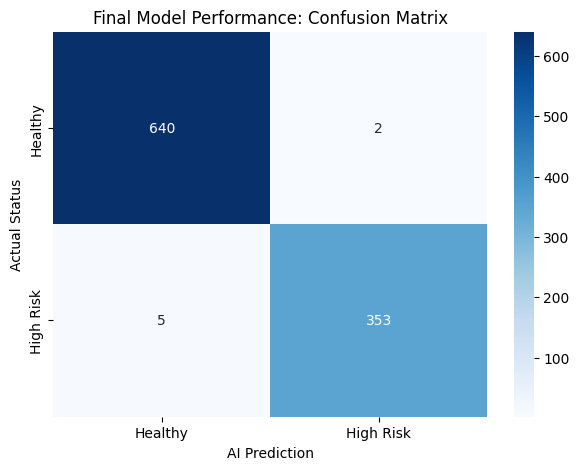


--- FINAL EVALUATION REPORT ---
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       642
         1.0       0.99      0.99      0.99       358

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

🎯 Final F1-Score: 0.9902


In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# --- 0. PATH SETUP (Critical for imports) ---
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

from src.model import SmartHealthLSTM

# --- 1. DATA LOADING (The part that fixes NameError) ---
data_path = '../data/processed/'
X_train = np.load(os.path.join(data_path, 'X_train.npy'))
X_test = np.load(os.path.join(data_path, 'X_test.npy'))
y_test = np.load(os.path.join(data_path, 'y_test.npy'))

# Prepare test_loader
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_test_t, y_test_t), batch_size=32
)

# --- 2. RE-INITIALIZE THE MODEL ARCHITECTURE ---
input_dim = X_train.shape[1] 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmartHealthLSTM(input_size=input_dim).to(device)

# --- 3. LOAD THE SAVED WEIGHTS ---
model_path = '../models/smart_health_lstm_model.pth'

if os.path.exists(model_path):
    # map_location ensures it works even if you move from GPU to CPU
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Model weights loaded successfully from models folder.")
else:
    print("❌ Error: model file not found at " + model_path)

# --- 4. EVALUATION MODE ---
model.eval() 
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        preds = (outputs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# --- 5. VISUALIZATION ---
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'High Risk'], 
            yticklabels=['Healthy', 'High Risk'])
plt.title('Final Model Performance: Confusion Matrix')
plt.xlabel('AI Prediction')
plt.ylabel('Actual Status')
plt.show()

print("\n--- FINAL EVALUATION REPORT ---")
print(classification_report(all_labels, all_preds))

f1 = f1_score(all_labels, all_preds)
print(f"🎯 Final F1-Score: {f1:.4f}")